# A/B Test Analysis

## Objective

Evaluate whether Variant B improves paid subscription conversion compared with Variant A.

### Primary Metric

- Paid Conversion Rate

### Secondary Metrics

- Revenue per Paying User
- Total Revenue

---

## Hypotheses

### Null Hypothesis (H₀)

There is no difference in paid conversion rate between Variant A and Variant B.

### Alternative Hypothesis (H₁)

Variant B has a different paid conversion rate than Variant A.

---

## Experiment Summary

Users were randomly assigned to one of two variants:

- Variant A (Control)
- Variant B (Treatment)

The objective is to determine whether the treatment produced a statistically significant improvement in paid conversion.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import chisquare

from statsmodels.stats.proportion import (
    proportions_ztest,
    confint_proportions_2indep
)

plt.style.use("ggplot")

# Load experiment dataset

In [17]:
df = pd.read_csv("../data/experiment_dataset.csv")

df.head()

,user_id,variant,signup_date,device,country,acquisition_channel,pre_engagement_7d,converted,retained,revenue
0,1,A,2024-10-19,mobile,UK,Organic,11,0,0,0.0
1,2,A,2024-06-24,desktop,US,Paid Search,14,0,0,0.0
2,3,B,2024-11-15,desktop,UK,Paid Search,7,0,0,0.0
3,4,B,2024-09-23,mobile,UK,Paid Search,14,0,0,0.0
4,5,B,2024-02-10,mobile,IN,Email,9,0,0,0.0


In [18]:
print(df.shape)

(40000, 10)


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              40000 non-null  int64  
 1   variant              40000 non-null  object 
 2   signup_date          40000 non-null  object 
 3   device               40000 non-null  object 
 4   country              38866 non-null  object 
 5   acquisition_channel  40000 non-null  object 
 6   pre_engagement_7d    40000 non-null  int64  
 7   converted            40000 non-null  int64  
 8   retained             40000 non-null  int64  
 9   revenue              40000 non-null  float64
dtypes: float64(1), int64(4), object(5)
memory usage: 3.1+ MB


In [20]:
summary = (
    df.groupby("variant")
      .agg(
          users=("user_id", "count"),
          conversions=("converted", "sum"),
          retained=("retained", "sum"),
          total_revenue=("revenue", "sum"),
          average_revenue_per_user=("revenue", "mean")
      )
)

summary["conversion_rate"] = (
    summary["conversions"]
    / summary["users"]
)

summary

,users,conversions,retained,total_revenue,average_revenue_per_user,conversion_rate
variant,,,,,,
A,19818,3440,2120,212616.0,10.728429,0.173580
B,20182,4083,2622,263820.0,13.072044,0.202309


## Initial Summary

The experiment contains approximately 20,000 users in each variant.

Variant B shows a higher observed paid conversion rate than Variant A prior to formal statistical testing.

In [16]:
variants = summary.index.to_list()

users = summary["users"].to_numpy()

conversions = summary["conversions"].to_numpy()

conversion_rates = summary["conversion_rate"].to_numpy()

total_revenue = summary["total_revenue"].to_numpy()

average_revenue_per_user = (
    summary["average_revenue_per_user"].to_numpy()
)

## Initial Observations

Before performing hypothesis testing, inspect the basic experiment metrics.

Questions:

- Was the experiment evenly split?
- Which variant converted better?
- Is there an obvious revenue difference?

In [4]:
absolute_uplift = conversion_rates[1] - conversion_rates[0]

relative_uplift = (
    absolute_uplift
    / conversion_rates[0]
) * 100

print(f"Variant A Conversion Rate : {conversion_rates[0]:.2%}")
print(f"Variant B Conversion Rate : {conversion_rates[1]:.2%}")

print()

print(f"Absolute Uplift : {absolute_uplift:.2%}")
print(f"Relative Uplift : {relative_uplift:.2f}%")

Variant A Conversion Rate : 17.36%
Variant B Conversion Rate : 20.23%

Absolute Uplift : 2.87%
Relative Uplift : 16.55%


## Visualization

Visualize the conversion rate for each experiment variant.

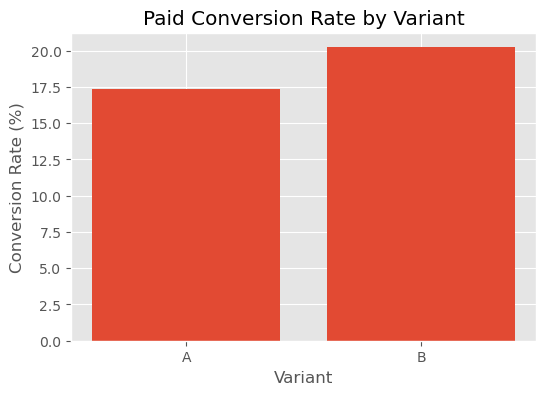

In [5]:
plt.figure(figsize=(6,4))

plt.bar(
    variants,
    conversion_rates * 100
)

plt.title("Paid Conversion Rate by Variant")

plt.ylabel("Conversion Rate (%)")

plt.xlabel("Variant")

plt.show()

## Sample Ratio Mismatch (SRM)

Before evaluating the experiment outcome, verify that users were assigned evenly between the two variants.

A significant imbalance may indicate an experiment implementation problem.

In [6]:
expected = [
    users.sum() / 2,
    users.sum() / 2
]

chi2, p = chisquare(
    f_obs=users,
    f_exp=expected
)

print("Chi-square statistic:", round(chi2, 4))

print("P-value:", round(p, 4))

Chi-square statistic: 3.3124
P-value: 0.0688


In [7]:
if p < 0.001:
    print("⚠️ Sample Ratio Mismatch detected.")
else:
    print("✅ Experiment allocation appears balanced.")

✅ Experiment allocation appears balanced.


## Two-Proportion Z-Test

The experiment assignment was balanced, so we can now evaluate whether the observed difference in paid conversion rates between Variant A and Variant B is statistically significant.

This test compares the conversion rates of the two variants under the following hypotheses:

**Null Hypothesis (H₀):**

There is no difference in paid conversion rate between Variant A and Variant B.

**Alternative Hypothesis (H₁):**

There is a difference in paid conversion rate between Variant A and Variant B.

In [8]:
z_stat, p_value = proportions_ztest(

    count=conversions,

    nobs=users

)

print(f"Z-statistic: {z_stat:.4f}")

print(f"P-value: {p_value:.6f}")

Z-statistic: -7.3517
P-value: 0.000000


In [9]:
alpha = 0.05

if p_value < alpha:
    print("✅ Reject the null hypothesis.")
    print("The difference in conversion rates is statistically significant.")
else:
    print("❌ Fail to reject the null hypothesis.")
    print("The observed difference could be due to random chance.")

✅ Reject the null hypothesis.
The difference in conversion rates is statistically significant.


## 95% Confidence Interval

While the hypothesis test tells us whether a statistically significant difference exists, a confidence interval estimates the range of plausible values for the true difference in conversion rates.

This helps quantify the magnitude and uncertainty of the observed uplift.

In [11]:
ci_low, ci_high = confint_proportions_2indep(
    count1=conversions[0],
    nobs1=users[0],
    count2=conversions[1],
    nobs2=users[1],
    method="wald"
)

print(f"95% Confidence Interval: ({ci_low:.4%}, {ci_high:.4%})")

95% Confidence Interval: (-3.6379%, -2.1079%)


## Confidence Interval Interpretation

The 95% confidence interval for the difference in conversion rates is:

**(-3.64%, -2.11%)**

The interval is entirely below zero because the calculation measures **Variant A − Variant B**.

Equivalently, Variant B improves paid conversion by approximately **2.11 to 3.64 percentage points** compared with Variant A.

Since the interval does not include zero, the observed improvement is statistically significant at the 95% confidence level.

## Segment Analysis

Overall conversion improved with Variant B, but treatment effects can differ across user segments.

This analysis evaluates whether the improvement is consistent across devices.